# 04 — Training: the loop, the speed, the comparison

Workflow step 4 is closed — baseline `exp_0001` ran, was submitted, and confirmed the
CV↔LB prediction. This notebook is the operating manual for step 5: what one
experiment actually does, how to iterate fast, and how to decide whether a change was
real. Display only; all logic lives in `src/s6e7/` (CLAUDE.md rule 5).

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import numpy as np
import polars as pl

from s6e7 import cv, io, plots

train = io.load_train()

---
## 1. What one experiment actually does

`cv.run(config)` is the whole training pipeline — nothing else trains models.

1. **`features.baseline_matrix`** — 13 raw columns become one float32 matrix. Every
   code is *declared* in the schema (`io.ORDINAL_LEVELS`, `io.NOMINAL_LEVELS`), never
   fitted on data, so nothing can leak across folds. Nulls become NaN and LightGBM
   routes them natively at each split.
2. **`features.encode_target`** — labels to codes 0/1/2 in `io.CLASSES` order.
3. **`folds.fold_vector`** — the frozen partition, joined by `id`, never by position.
4. **Five times:** a *fresh* model from the registry → fit on four folds (552k rows) →
   `predict_proba` on the held-out 138k → those probabilities land in the OOF matrix
   at exactly those rows → argmax → balanced accuracy for that fold.
5. **Artifacts:** OOF probabilities to `oof/<exp_id>.npy`, test probabilities (the
   five fold-models averaged) to `oof/<exp_id>_test.npy`, and one append-only row in
   `experiments.csv`. `run` refuses an exp_id it has already seen.

Extension points, deliberately boring: a new model family is one small builder file in
`src/s6e7/models/`; voting, stacking and the decision-rule search all read the saved
OOF matrices and never retrain anything.

In [2]:
pl.read_csv(cv.LEDGER)

exp_id,date,config,model,folds,cv_mean,cv_std,lb_public,oof_path,runtime_s,parent,changed
str,str,str,str,str,f64,f64,f64,str,i64,str,str
"""exp_0001""","""2026-08-30""","""configs/exp_0001.yaml""","""lgbm""","""stratified5_seed42""",0.87291,0.00205,0.8721,"""oof/exp_0001.npy""",58,null,"""first baseline: LGBM defaults,…"


---
## 2. Iterating fast

The full baseline takes ~60 s locally, so full runs are the default. When a config is
genuinely slow (heavy `n_estimators`, CatBoost), smoke-test the *code* first on a 10%
subsample with `log=False` — the ledger must never see a subsample number, because a
10% score has ~3× the noise and a different training size; it tests plumbing, not
ideas. The frozen folds still apply (the subsample's ids join cleanly).

In [3]:
sub = train.sample(fraction=0.10, seed=42)
smoke = cv.run(
    cv.ExperimentConfig("smoke", "lgbm"),
    train=sub, log=False, oof_dir=io.PROCESSED / "smoke_oof",
)
print(f"10% smoke: {smoke.cv_mean:.5f} ± {smoke.cv_std:.5f} in {smoke.runtime_s:.0f}s")

10% smoke: 0.87113 ± 0.00321 in 8s


---
## 3. When is a change real?

The bell below is the wobble of `cv_mean` when *nothing changed* — validation luck
alone, SE ≈ 0.001 (derived in LEARNING.md from per-class counts). A candidate gain is
judged by how many SE it clears, not by whether it is positive: **+0.0005 is the
instrument rattling; +0.005 is a result.**

Two refinements to keep in mind:

- **Paired comparisons resolve finer.** Two experiments on the identical frozen folds
  share their validation luck, and it cancels out of the difference — which is why the
  folds are frozen (LEARNING.md). The bell is the conservative bar.
- **`cv_std` is a per-run sanity check.** Expect ≈ 0.002; a run reporting 0.006 is a
  broken run, not a noisy idea.

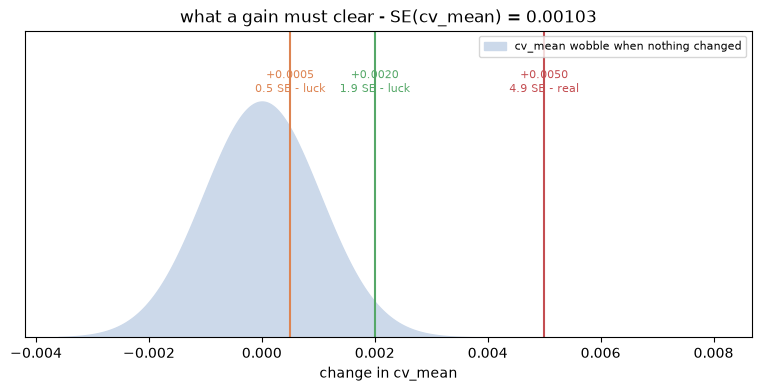

In [4]:
plots.resolution_demo()

---
## 4. Reading the baseline

`exp_0001` (LGBM defaults, raw features, argmax): **CV 0.87291 ± 0.00205**, public LB
0.87210 (CV − 0.0008), private 0.87171 (CV − 0.0012) — the predicted level gap, sign
and magnitude. Three readings from the diagnostics:

- **Reliability sits on the diagonal** — the probabilities are trustworthy, so the
  decision-rule search (exp_0002) gets to work with clean inputs.
- **Errors flow into `at-risk`**: fit→at-risk 17.2%, unhealthy→at-risk 19.8%. That is
  the training-prior effect — argmax favours the 86% class — and it is exactly what
  per-class multipliers correct.
- **`fit` (0.825) and `unhealthy` (0.801) are the bottleneck**; the macro metric
  weighs their recall equally with the 99.3% `at-risk`.

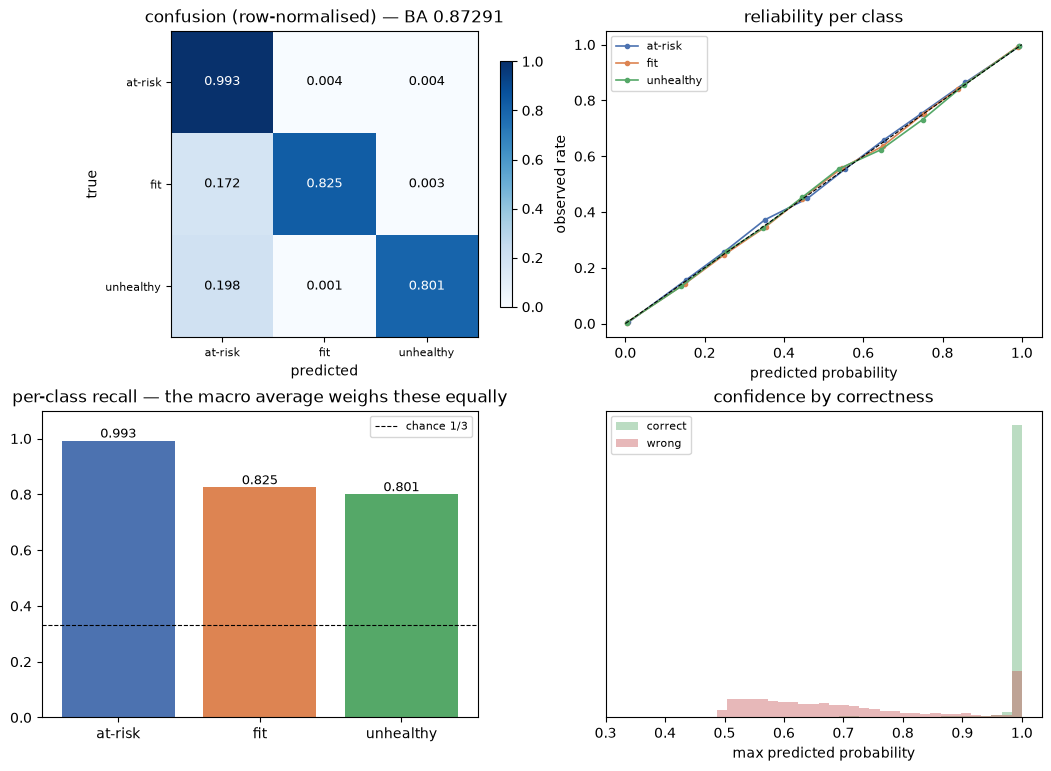

In [5]:
oof = np.load(cv.OOF_DIR / "exp_0001.npy")
plots.oof_diagnostics(train[io.TARGET].to_numpy(), oof)

Balanced accuracy by null count `k` — the per-slice watchdog from the fold decision.
The fall from k=0 to k≥3 is expected: rows missing more features are simply harder.
The watchdog is the *shape* of this profile — it should stay put from experiment to
experiment, and it is the first table to check whenever a change touches missing-data
handling, the single axis the train/test shift could mis-rank.

In [6]:
cv.slice_report("exp_0001")

slice,n_rows,balanced_acc,recall_at-risk,recall_fit,recall_unhealthy
str,i64,f64,f64,f64,f64
"""all""",690088,0.87291,0.9927,0.8254,0.8007
"""k=0""",349623,0.96723,0.9984,0.9452,0.9581
"""k=1""",248134,0.81493,0.9877,0.7578,0.6993
"""k=2""",77311,0.68396,0.9845,0.5851,0.4823
"""k>=3""",15020,0.57953,0.9851,0.4371,0.3164


---
## 5. The road ahead — and is one GBDT enough?

One variable per experiment, ids reserved in order (models and parameters stay the
operator's call — this is the proposal):

| exp | one change | why it is next |
|---|---|---|
| exp_0002 | decision rule: per-class multipliers searched on OOF | free score — no retraining, 2 parameters, targets exactly the error flow above |
| exp_0003 | native categorical handling instead of integer codes | one flag, tests the encoding assumption |
| exp_0004 | capacity: more trees at a lower learning rate | defaults (100 trees) almost surely underfit 690k rows |
| exp_0005+ | operator feature ideas from `features.py` | one idea per id |

**Is one GBDT enough?** For the best *single* model — nearly: a well-tuned LightGBM,
XGBoost, or CatBoost typically land within ~0.001–0.003 of each other, so switching
families buys little on its own. Their value is **diversity**: they make different
errors, and a vote/blend/stack over decorrelated OOF probabilities is what beats the
best single. XGBoost and CatBoost therefore join *after* the LGBM
line is tuned, as blend members; a linear model or NN joins only if its OOF errors
decorrelate from the trees'.

**Hyperparameter tuning (Optuna) comes after the feature set stabilises** — tuning
first spends its budget re-tuning after every feature change.